## ImageNet experiments
imagenet 데이터를 사용한 실험
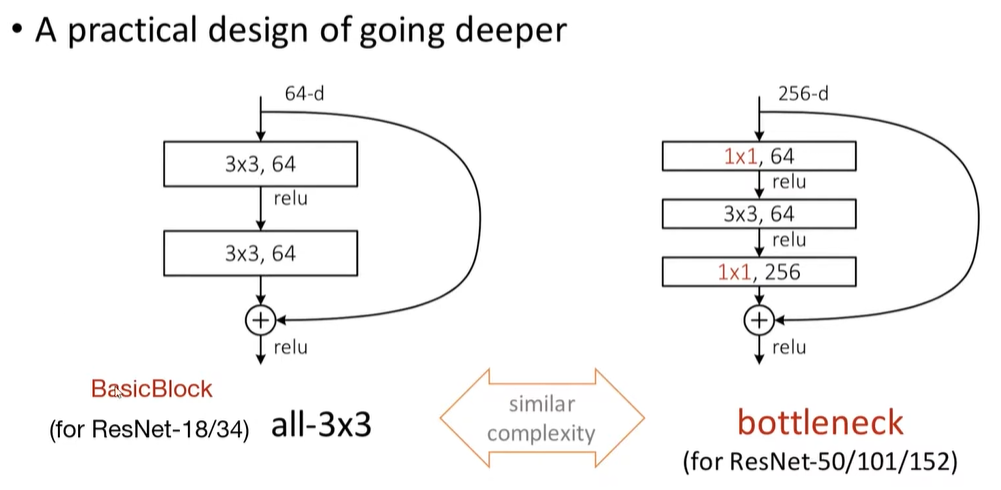
- 일반적 인공신경망은 학습하면서 데이터 특징을 조금씩 변형시키고 깎음 -> 처음에 뭐가 들어왔었는지 까먹거나 데이터 오염 방지 위해 자기 자신을 더함 = shortcut connection
- 미분하면 F(x) + x -> 1 은 무조건 남아 gradient 소실도 발생 x
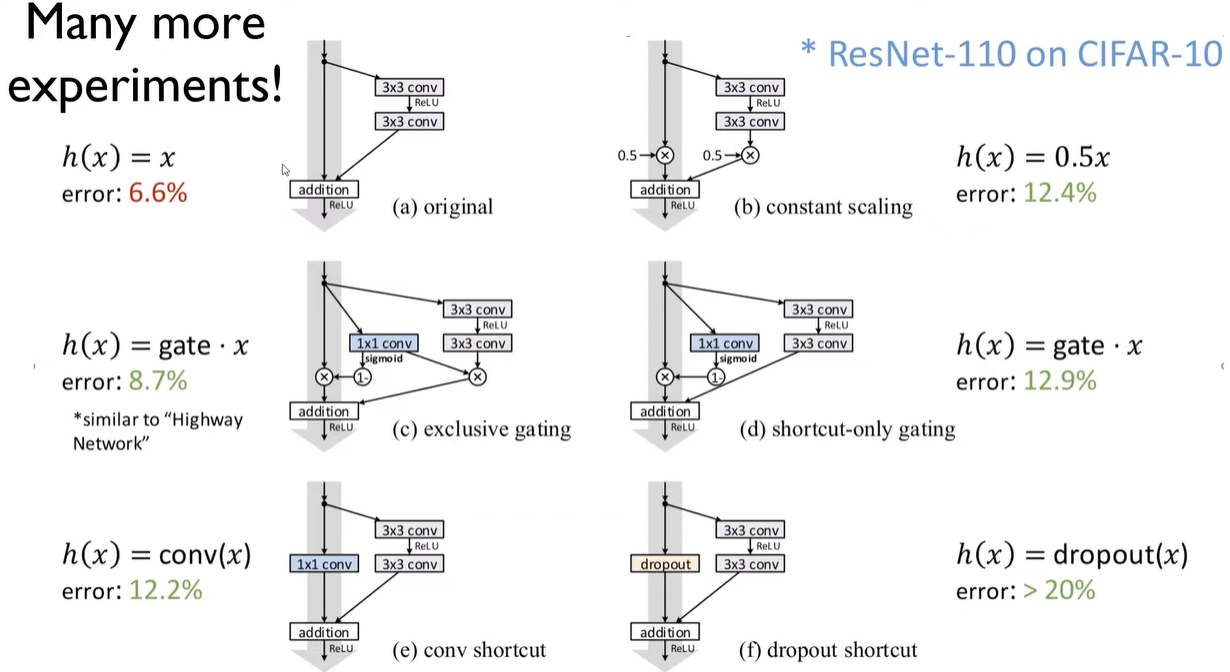

ResNet 논문 : 복잡하게 만들지 말고 있는 그대로 identity 전달이 가장 효과적임.
- 실험 핵심 포인트
1. 더하기만 하고 곱하기는 하지 마라. : 0.5를 곱하거나 게이트를 달아 곱셈 연산 추가하니 성능 떨어짐. -> 곱셈 들어가는 순간 역전파 때 미분값이 작아지면서 기울기 소실 문제 발생 가능.
2. 지름길은 투명해야 한다. : 1x1 conv나 드롭아웃 걸어 정보 변형 시 원래 전달하려던 원본 데이터의 순수함 깨짐.
3. 그냥 놔두는 게 제일 빨랐다. : data와 gradient가 방해받지 않고 흐를 수 있는 깨끗한 고속도로를 만드는 것이 최고. 

In [1]:
import torch.nn as nn
import torch.utils.model_zoo as model_zoo

__all__ = ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152']

model_urls = {
    'resnet18' : 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34' : 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50' : 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101' : 'https://download.pytorch.org/models/resnet101-5d3b4dd8f.pth',
    'resnet152' : 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
}

In [2]:
def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)

def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride
    
    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:  # stride가 커지면 out의 샘플 크기와 identity 크기가 달라져서 방지 위해 사용. 
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [6]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = conv1x1(inplanes, planes)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = conv3x3(planes, planes, stride)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = conv1x1(planes, planes * self.expansion) # 채널 개수가 배로 뜀
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [ ]:
class ResNet(nn.Module):
    # model = ResNet(Bottleneck, [3, 4, 6, 3], **kwargs) = resnet50
    def __init__(self, block, layers, num_classes=1000, zero_init_residual=False):
        super(ResNet, self).__init__()
        self.inplanes = 64

        # inputs = 3 x 224 x 224
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # outputs = self.conv1(inputs)
        # outputs.shape = [64x112x112]

        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # inputs = [64x112x112]
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # output = [64x56x56]
        self.layer1 = self._make_layer(block, 64, layers[0]) # 3
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2) # 4
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2) # 6
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2) # 3
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.weight, 1)
                    nn.init.constant_(m.bais, 0)
        
    def _make_layer(self, block, planes, blocks, stride=1):
        downsample=None
        if stride != 1 or self.inplanes != planes * block.expansion: # 64 != 64 * 4
            # downsample을 채널을 맞추기 위해 사용 
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride), # conv1x1(64, 256, stride=1)
                nn.BatchNorm2d(planes * block.expansion), # batchnorm2d(256)
            )
        
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        # layers.append(Bottleneck(64, 64, 1, downsample))
        self.inplanes = planes * block.expansion # self.inplanes = 256
        for _ in range(1, blocks):
            #blocks = 3
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)
    
    '''
    self.layer1 = {
        Bottleneck(64, 64, 1, downsample)
        Bottleneck(256, 64)
        Bottleneck(256, 64)
    }
    self.layer2 = {
        Bottleneck(256, 128, 2, downsample)
        Bottleneck(512, 128)
        Bottleneck(512, 128)
        Bottleneck(512, 128)}
    '''

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.maxpool(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)

        return out

In [ ]:
def resnet18(pretrained=False, **kwargs):
    # 레이어 수 : 2 (basicblock) * (2 + 2 + 2 + 2) + 1 (맨 앞 conv하나) + 1 (fc) = 18
    '''Constructs a ResNet-18 model

    Args:
        pretrained (bool) : if True, returns a model pre-trained on imageNet
    '''
    model = ResNet(BasicBlock, [2, 2, 2, 2], **kwargs)
    if pretrained:
        model.load_state_dict(model_zoo.load_url(model_urls['resnet18']))
    return model

In [22]:
def resnet50(pretrained=False, **kwargs):
    # 레이어 수 : 3 (bottleneck) * (3 + 4 + 6 + 3) + 1(conv1) + 1(fc) = 50
    '''Constructs a ResNet-50 model

    Args:
        pretrained (bool) : if True, returns a model pre-trained on imageNet
    '''
    model = ResNet(Bottleneck, [3, 4, 6, 3], **kwargs)
    if pretrained:
        model.load_state_dict(model_zoo.load_url(model_urls['resnet18']))
    return model

In [20]:
res = resnet50()
print(res)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
import torchvision.models.resnet as resnet
res = resnet.resnet50()